# Design a working controller

## 1. Set up the notebook

### 1.1 Do imports

Do imports.

In [1030]:
import numpy as np
import sympy as sym
from scipy import linalg
import matplotlib.pyplot as plt
from ae483.tools import *
from ae483.mytools import *
from ae483.design import *

### 1.2 Create an LQR solver

Define a function that solves the linear quadratic regulator (LQR) problem.

In [1031]:
def lqr(A, B, Q, R):
    P = linalg.solve_continuous_are(A, B, Q, R)
    K = linalg.inv(R) @  B.T @ P
    return K

## 2. Derive equations of motion

### 2.1 Define symbolic variables

Define states.

In [1032]:
# components of position (meters)
p_x, p_y, p_z = sym.symbols('p_x, p_y, p_z')

# yaw, pitch, and roll angles (radians)
psi, theta, phi = sym.symbols('psi, theta, phi')

# components of linear velocity (meters / second)
v_x, v_y, v_z = sym.symbols('v_x, v_y, v_z')

# components of angular velocity (radians / second)
w_x, w_y, w_z = sym.symbols('w_x, w_y, w_z')

# torque states
tau_x, tau_y = sym.symbols('tau_x, tau_y')

# error states
e_x, e_y, e_z = sym.symbols('e_x, e_y, e_z')

Define inputs.

In [1033]:
# components of net rotor torque
tau_x_cmd, tau_y_cmd, tau_z = sym.symbols('tau_x_cmd, tau_y_cmd, tau_z')

# net rotor force
f_z = sym.symbols('f_z')

Define parameters.

In [1034]:
m, J_x, J_y, J_z, g, T_F = sym.symbols('m, J_x, J_y, J_z, g, T_F')

Create the linear velocity vector $v^B_{W, B}$ and the angular velocity vector $w^B_{W, B}$, both written in the coordinates of the body frame.

In [1035]:
v_inB_ofWB = sym.Matrix([v_x, v_y, v_z])
w_inB_ofWB = sym.Matrix([w_x, w_y, w_z])

Create moment of inertia matrix (in coordinates of the body frame).

In [1036]:
J_inB = sym.diag(J_x, J_y, J_z)

### 2.2 Define kinematics of orientation

#### 2.2.1 Rotation matrix in terms of yaw, pitch, roll angles

Define individual rotation matrices.

In [1037]:
Rz = sym.Matrix([[sym.cos(psi), -sym.sin(psi), 0],
                 [sym.sin(psi), sym.cos(psi), 0],
                 [0, 0, 1]])

Ry = sym.Matrix([[sym.cos(theta), 0, sym.sin(theta)],
                 [0, 1, 0],
                 [-sym.sin(theta), 0, sym.cos(theta)]])

Rx = sym.Matrix([[1, 0, 0],
                 [0, sym.cos(phi), -sym.sin(phi)],
                 [0, sym.sin(phi), sym.cos(phi)]])

Apply sequential transformation to compute the rotation matrix that describes the orientation of the drone (i.e., of frame $B$ in the coordinates of frame $W$).

In [1038]:
R_inW_ofB = Rz @ Ry @ Rx

#### 2.2.2 Map from angular velocity to angular rates

Recall that

$$\begin{bmatrix} \dot{\psi} \\ \dot{\theta} \\ \dot{\phi} \end{bmatrix} = N w_{W, B}^{B}$$

for some matrix $N$. Here is how to compute that matrix for a ZYX (yaw, pitch, roll) Euler angle sequence.  First, we compute its inverse:

In [1039]:
Ninv = sym.Matrix.hstack((Ry @ Rx).T @ sym.Matrix([0, 0, 1]),
                              (Rx).T @ sym.Matrix([0, 1, 0]),
                                       sym.Matrix([1, 0, 0]))

Then, we compute $N$ by taking the inverse of $N^{-1}$:

In [1040]:
N = sym.simplify(Ninv.inv())

### 2.3 Define equations of motion

Forces.

In [1041]:
f_inB = R_inW_ofB.T @ sym.Matrix([0, 0, -m * g]) + sym.Matrix([0, 0, f_z])

Torques.

In [1042]:
tau_inB = sym.Matrix([tau_x, tau_y, tau_z])

Time delay

In [1043]:
time_delay = sym.Matrix([(1/T_F) * (tau_x_cmd - tau_x), 
                         (1/T_F) * (tau_y_cmd - tau_y)])

Errors

In [1044]:
error = sym.Matrix([p_x, p_y, p_z])

Create equations of motion.

In [1045]:
f_sym = sym.Matrix.vstack(
    R_inW_ofB @ v_inB_ofWB,
    N @ w_inB_ofWB,
    (1 / m) * (f_inB - w_inB_ofWB.cross(m * v_inB_ofWB)),
    J_inB.inv() @ (tau_inB - w_inB_ofWB.cross(J_inB @ w_inB_ofWB)),
    time_delay,
    error
)

Show the right-hand side of the equations of motion, which have the form

$$\dot{s} = f(s, i, p)$$

for states

$$
s = \begin{bmatrix} p_x \\ p_y \\ p_z \\ \psi \\ \theta \\ \phi \\ v_x \\ v_y \\ v_z \\ w_x \\ w_y \\ w_z \\ \tau_x \\ \tau_y \\e_x \\e_y \\e_z \end{bmatrix},
$$

inputs
$$
i = \begin{bmatrix} \tau_{x,cmd} \\ \tau_{y,cmd} \\ \tau_z \\ f_z \end{bmatrix},
$$

and parameters
$$
p = \begin{bmatrix} m \\ J_x \\ J_y \\ J_z \\ g \end{bmatrix}.
$$

In [1046]:
f_sym

Matrix([
[ v_x*cos(psi)*cos(theta) + v_y*(sin(phi)*sin(theta)*cos(psi) - sin(psi)*cos(phi)) + v_z*(sin(phi)*sin(psi) + sin(theta)*cos(phi)*cos(psi))],
[v_x*sin(psi)*cos(theta) + v_y*(sin(phi)*sin(psi)*sin(theta) + cos(phi)*cos(psi)) + v_z*(-sin(phi)*cos(psi) + sin(psi)*sin(theta)*cos(phi))],
[                                                                       -v_x*sin(theta) + v_y*sin(phi)*cos(theta) + v_z*cos(phi)*cos(theta)],
[                                                                                         w_y*sin(phi)/cos(theta) + w_z*cos(phi)/cos(theta)],
[                                                                                                               w_y*cos(phi) - w_z*sin(phi)],
[                                                                                   w_x + w_y*sin(phi)*tan(theta) + w_z*cos(phi)*tan(theta)],
[                                                                                                (g*m*sin(theta) + m*v_y*w_z - m*v_z*w_y)/m

## 3. Derive state-space model

### 3.1 Choose equilibrium point

An equilibrium point of the nonlinear system is a choice of states $s_\text{eq}$ and inputs $i_\text{eq}$ — along with constant parameters $p_\text{eq}$ — for which

$$0 = f(s_\text{eq}, i_\text{eq}, p_\text{eq}).$$

Create a list of states, inputs, and parameters as symbolic variables.

In [1047]:
s = [p_x, p_y, p_z, psi, theta, phi, v_x, v_y, v_z, w_x, w_y, w_z, tau_x, tau_y, e_x, e_y, e_z]
i = [tau_x_cmd, tau_y_cmd, tau_z, f_z]
p = [m, J_x, J_y, J_z, g, T_F]

Create a list of states to track as symbolic variables. These are states whose desired values will be specified by a client.

In [1048]:
s_with_des = [p_x, p_y, p_z]

Create a function that evaluates $f(\cdot)$ at particular values of $s$, $i$, and $p$.

In [1049]:
f = sym.lambdify(s + i + p, f_sym)

Define constants.

In [1050]:
# Mass
m = 32*1e-3 # <-- FIXME

# Principle moments of inertia
J_x = 1.63e-05  # <-- FIXME
J_y = 1.61e-05  # <-- FIXME
J_z = 3.02e-05  # <-- FIXME

# Acceleration of gravity
g = 9.81

# Time delay constant
T_F = 0.066

Create a list of parameter values in the **same order** as the symbolic list. These are the parameter estimates we found in our experiments. They are not choices. (We use the subscript `_eq` to be consistent with what follows, and could say "parameter values *at equilibrium*," but don't be misled. These parameter values are *given* and are *constant* - again, they aren't choices.)

In [1051]:
p_eq = [m, J_x, J_y, J_z, g, T_F]

Create a list of state and input values at equilibrium in the **same order** as the symbolic lists.

In [1052]:
# s = [p_x, p_y, p_z, psi, theta, phi, v_x, v_y, v_z, w_x, w_y, w_z, tau_x, tau_y, e_x, e_y, e_z]
# i = [tau_x, tau_y, tau_z, f_z]
# p = [m, J_x, J_y, J_z, g, T_F]

s_eq = [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.] # <-- FIXME
i_eq = [0., 0., 0., m*g]                                 # <-- FIXME



Evaluate the equations of motion at the equilibrium point — if it actually *is* an equilibrium point, then the result should be an array of zeros:

In [1053]:
print(f(*s_eq, *i_eq, *p_eq))
assert(np.allclose(f(*s_eq, *i_eq, *p_eq), 0.))

[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


Note that this equilibrium point would remain an equilibrium point for any choice of `p_x`, `p_y`, and `p_z` — that is one thing that allows the controller to track desired values of these variables.

### 3.2 Compute A and B

We want to find

$$
A = \frac{\partial f}{\partial s}\biggr\vert_{(s, i, p) = (s_\text{eq}, i_\text{eq}, p_\text{eq})}
\qquad\text{and}\qquad
B = \frac{\partial f}{\partial i}\biggr\vert_{(s, i, p) = (s_\text{eq}, i_\text{eq}, p_\text{eq})}.
$$

First, we compute each Jacobian (i.e., each matrix of partial derivatives) in symbolic form.

In [1054]:
A_sym = f_sym.jacobian(s)
B_sym = f_sym.jacobian(i)

Then, we create functions that allow us to evaluate these Jacobians at particular values of $s$, $i$, and $p$.

In [1055]:
A_num = sym.lambdify(s + i + p, A_sym)
B_num = sym.lambdify(s + i + p, B_sym)

Finally, we plug in our equilibrium point.

In [1056]:
A = A_num(*s_eq, *i_eq, *p_eq)
B = B_num(*s_eq, *i_eq, *p_eq)

Show $A$ (formatted nicely).

In [1057]:
A_str = np.array2string(A,
                        formatter={'float_kind': lambda x: f'{x:6.3f}'},
                        prefix='    ',
                        max_line_width=np.inf)

print(f'A = {A_str}')

A = [[ 0.000  0.000  0.000  0.000  0.000  0.000  1.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
     [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  1.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
     [ 0.000  0.000  0.000  0.000 -0.000  0.000 -0.000  0.000  1.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
     [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  1.000  0.000  0.000  0.000  0.000  0.000]
     [ 0.000  0.000  0.000  0.000  0.000 -0.000  0.000  0.000  0.000  0.000  1.000 -0.000  0.000  0.000  0.000  0.000  0.000]
     [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  1.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
     [ 0.000  0.000  0.000  0.000  9.810  0.000  0.000  0.000 -0.000  0.000 -0.000  0.000  0.000  0.000  0.000  0.000  0.000]
     [ 0.000  0.000  0.000  0.000  0.000 -9.810 -0.000  0.000  0.000  0.000  0.000 -0.000  0.000  0.000  0.000  0.000 

Show $B$ (formatted nicely).

In [1058]:
B_str = np.array2string(B,
                        formatter={'float_kind': lambda x: f'{x:11.3f}'},
                        prefix='    ',
                        max_line_width=np.inf)

print(f'B = {B_str}')

B = [[      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000      31.250]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000   33112.583       0.000]
     [     15.152       0.000       0.000       0.000]
     [      0.000      15.152       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]
     [      0.000       0.000       0.000       0.000]]


The state-space system is described by

$$ \dot{x} = Ax + Bu $$

where

$$ x = s - s_\text{eq} $$

and

$$ u = i - i_\text{eq}. $$

Note that $A$ and $B$ would remain the same for any choice of `p_x`, `p_y`, and `p_z` — that is another thing that allows the controller to track desired values of these variables.

## 4. Design method of power distribution

Define constants.

In [1059]:
k_F = 1.46e-06 # <-- FIXME
k_M = 6.98e-09 # <-- FIXME
l = 3.1819805153 * 1e-2   # <-- FIXME

Define the matrix $P$ that maps motor power commands ($m_1$, $m_2$, $m_3$, $m_4$) to inputs ($\tau_x$, $\tau_y$, $\tau_z$, $f_z$).

In [1060]:
P = np.array([[ -l * k_F, -l * k_F,  l * k_F,  l * k_F  ],
              [ -l * k_F, l * k_F,   l * k_F,  -l * k_F ],
              [ -k_M,     k_M,       -k_M,     k_M      ],
              [ k_F,      k_F,       k_F,      k_F      ]])

Compute the matrix $P^{-1}$ that maps inputs to motor power commands.

In [1061]:
Pinv = linalg.inv(P)

Show the matrix $P^{-1}$ (formatted nicely).

In [1062]:
Pinv_str = np.array2string(Pinv,
                           formatter={'float_kind': lambda x: f'{x:12.1f}'},
                           prefix='         ',
                           max_line_width=np.inf)

print(f'inv(P) = {Pinv_str}')

inv(P) = [[  -5381330.1   -5381330.1  -35816618.9     171232.9]
          [  -5381330.1    5381330.1   35816618.9     171232.9]
          [   5381330.1    5381330.1  -35816618.9     171232.9]
          [   5381330.1   -5381330.1   35816618.9     171232.9]]


Print code that implements the method of power distribution in C (compare this code to $P^{-1}$).

In [1063]:
export_power_distribution(
    Pinv,
    i=i,
    limiter='limitUint16',
    suffix='f',
    line_ending=';',
)

m_1 = limitUint16( -5381330.1f * tau_x_cmd -5381330.1f * tau_y_cmd -35816618.9f * tau_z + 171232.9f * f_z );
m_2 = limitUint16( -5381330.1f * tau_x_cmd + 5381330.1f * tau_y_cmd + 35816618.9f * tau_z + 171232.9f * f_z );
m_3 = limitUint16( 5381330.1f * tau_x_cmd + 5381330.1f * tau_y_cmd -35816618.9f * tau_z + 171232.9f * f_z );
m_4 = limitUint16( 5381330.1f * tau_x_cmd -5381330.1f * tau_y_cmd + 35816618.9f * tau_z + 171232.9f * f_z );


## 5. Design, implement, and test a sequence of controllers

Decide which inputs will depend on which states — we call this the **gain structure**.

In [1064]:
# Find the gain structure
structure = gain_structure(A, B, s, i)

# Show the gain structure
structure

{'tau_x_cmd': ['p_y', 'phi', 'v_y', 'w_x', 'tau_x', 'e_y'],
 'tau_y_cmd': ['p_x', 'theta', 'v_x', 'w_y', 'tau_y', 'e_x'],
 'tau_z': ['psi', 'w_z'],
 'f_z': ['p_z', 'v_z', 'e_z']}

Print code that defines all gains in C, with placeholder values.

In [1065]:
export_declarations(structure)

// Gains (these are set by flight.py - do not edit the values here)
static float eq_tau_x_cmd = 0.0f;
static float k_tau_x_cmd_p_y = 0.0f;
static float k_tau_x_cmd_phi = 0.0f;
static float k_tau_x_cmd_v_y = 0.0f;
static float k_tau_x_cmd_w_x = 0.0f;
static float k_tau_x_cmd_tau_x = 0.0f;
static float k_tau_x_cmd_e_y = 0.0f;
static float eq_tau_y_cmd = 0.0f;
static float k_tau_y_cmd_p_x = 0.0f;
static float k_tau_y_cmd_theta = 0.0f;
static float k_tau_y_cmd_v_x = 0.0f;
static float k_tau_y_cmd_w_y = 0.0f;
static float k_tau_y_cmd_tau_y = 0.0f;
static float k_tau_y_cmd_e_x = 0.0f;
static float eq_tau_z = 0.0f;
static float k_tau_z_psi = 0.0f;
static float k_tau_z_w_z = 0.0f;
static float eq_f_z = 0.0f;
static float k_f_z_p_z = 0.0f;
static float k_f_z_v_z = 0.0f;
static float k_f_z_e_z = 0.0f;


Print code that makes each gain a parameter in C, so that the actual value of each gain can be sent to the drone by the client just before each flight.

In [1066]:
export_parameter_block(structure)

//                1234567890123456789012345 <-- max total length
//                group .name
PARAM_GROUP_START(ae483g)
PARAM_ADD(PARAM_FLOAT,   eq_tau_x_cmd,            &eq_tau_x_cmd)
PARAM_ADD(PARAM_FLOAT,   k_tau_x_cmd_p_y,         &k_tau_x_cmd_p_y)
PARAM_ADD(PARAM_FLOAT,   k_tau_x_cmd_phi,         &k_tau_x_cmd_phi)
PARAM_ADD(PARAM_FLOAT,   k_tau_x_cmd_v_y,         &k_tau_x_cmd_v_y)
PARAM_ADD(PARAM_FLOAT,   k_tau_x_cmd_w_x,         &k_tau_x_cmd_w_x)
PARAM_ADD(PARAM_FLOAT,   k_tau_x_cmd_tau_x,       &k_tau_x_cmd_tau_x)
PARAM_ADD(PARAM_FLOAT,   k_tau_x_cmd_e_y,         &k_tau_x_cmd_e_y)
PARAM_ADD(PARAM_FLOAT,   eq_tau_y_cmd,            &eq_tau_y_cmd)
PARAM_ADD(PARAM_FLOAT,   k_tau_y_cmd_p_x,         &k_tau_y_cmd_p_x)
PARAM_ADD(PARAM_FLOAT,   k_tau_y_cmd_theta,       &k_tau_y_cmd_theta)
PARAM_ADD(PARAM_FLOAT,   k_tau_y_cmd_v_x,         &k_tau_y_cmd_v_x)
PARAM_ADD(PARAM_FLOAT,   k_tau_y_cmd_w_y,         &k_tau_y_cmd_w_y)
PARAM_ADD(PARAM_FLOAT,   k_tau_y_cmd_tau_y,       &k_tau_y_cmd_ta

Print code that implements the controller in C.

In [1067]:
export_controller(structure, s_with_des)

tau_x_cmd = eq_tau_x_cmd - (k_tau_x_cmd_p_y * (p_y - p_y_des) + k_tau_x_cmd_phi * phi + k_tau_x_cmd_v_y * v_y + k_tau_x_cmd_w_x * w_x + k_tau_x_cmd_tau_x * tau_x + k_tau_x_cmd_e_y * e_y);
tau_y_cmd = eq_tau_y_cmd - (k_tau_y_cmd_p_x * (p_x - p_x_des) + k_tau_y_cmd_theta * theta + k_tau_y_cmd_v_x * v_x + k_tau_y_cmd_w_y * w_y + k_tau_y_cmd_tau_y * tau_y + k_tau_y_cmd_e_x * e_x);
tau_z = eq_tau_z - (k_tau_z_psi * psi + k_tau_z_w_z * w_z);
f_z = eq_f_z - (k_f_z_p_z * (p_z - p_z_des) + k_f_z_v_z * v_z + k_f_z_e_z * e_z);


### 5.x Flight test (template)

Choose the weighting matrices $Q$ and $R$.

In [1068]:
# s = [p_x, p_y, p_z, psi, theta, phi, v_x, v_y, v_z, w_x, w_y, w_z, tau_x, tau_y]
# i = [tau_x_cmd, tau_y_cmd, tau_z, f_z]
# p = [m, J_x, J_y, J_z, g]
Q = np.diag([
    50.,
    50.,
    500.,
    100.,
    50.,
    50.,
    1.,
    1.,
    1.,
    1.,
    1.,
    1.,
    1.,
    1.,
    1.,
    1.,
    20.,
]) / 10.


# Bryson's rule for R
# Motor power command at hover
m_hover = (m * g) / (4 * k_F)

# Max change to each motor power command so that it stays within [0, 65535]
c = min(m_hover, 65535 - m_hover)

# Max change to each motor power command to accommodate a change in any one input
delta = c / 4

# Max value of each input u = [tau_x, tau_y, tau_z, f_z - m g]
u_max = np.array([
    4 * k_F * l * delta,    # tau_x
    4 * k_F * l * delta,    # tau_y
    4 * k_M * delta,        # tau_z
    4 * k_F * delta,        # f_z - m g
])

R = np.diag(1 / u_max**2)

Find the gain matrix $K$.

In [1069]:
K = lqr(A, B, Q, R)

Show $K$ (formatted nicely).

In [1070]:
K_str = np.array2string(K,
                        formatter={'float_kind': lambda x: f'{x:8.5f}'},
                        prefix='    ',
                        max_line_width=np.inf)

print(f'K = {K_str}')

K = [[ 0.00000 -0.00135 -0.00000  0.00000  0.00000  0.00303  0.00000 -0.00092 -0.00000  0.00048  0.00000  0.00000  1.20691  0.00000  0.00000 -0.00017 -0.00000]
     [ 0.00135 -0.00000  0.00000 -0.00000  0.00302  0.00000  0.00092 -0.00000  0.00000  0.00000  0.00048 -0.00000  0.00000  1.21326  0.00017 -0.00000  0.00000]
     [-0.00000 -0.00000  0.00000  0.00026 -0.00000  0.00000 -0.00000 -0.00000  0.00000  0.00000 -0.00000  0.00013  0.00000 -0.00000 -0.00000 -0.00000  0.00000]
     [ 0.00000  0.00000  0.13926  0.00000  0.00000 -0.00000  0.00000  0.00000  0.09456 -0.00000  0.00000  0.00000 -0.00000  0.00000  0.00000  0.00000  0.02433]]


Show code that would implement your controller in C if you were to hard-code the gains as numbers. **Do not use this code!** It is only for the purpose of understanding. Instead, you should be using the code from `export_controller()` with gains as parameters, the values of which will be sent by the client to the drone just before each flight.

In [1071]:
show_controller(
    K,               # the gain matrix
    s,               # list of states as symbolic variables
    i,               # list of inputs as symbolic variables
    s_with_des,      # list of states that have desired values as symbolic variables
    i_eq,            # list of equilibrium values of inputs
    suffix='f',      # character to print after each number (indicates a "float")
    line_ending=';'  # character to print after each line
)

tau_x_cmd = 0.00134763f * (p_y - p_y_des) -0.00302836f * phi + 0.00091931f * v_y -0.00047794f * w_x -1.20691281f * tau_x + 0.00017308f * e_y;
tau_y_cmd = -0.00134749f * (p_x - p_x_des) -0.00302083f * theta -0.00091818f * v_x -0.00047550f * w_y -1.21325747f * tau_y -0.00017308f * e_x;
tau_z = -0.00026005f * psi -0.00012800f * w_z;
f_z = -0.13926476f * (p_z - p_z_des) -0.09456496f * v_z -0.02432603f * e_z + 0.31392000f;


Write the gain values to a JSON file for the client to send to the drone. By default, this file is called `gains.json` and is placed in the same directory as this notebook.

In [1072]:
export_gains(
    K,               # the gain matrix
    structure,       # the gain structure
    s,               # list of states as symbolic variables
    i,               # list of inputs as symbolic variables
    i_eq,            # list of equilibrium values of inputs
)

Wrote 21 gains to gains.json at 2026-10-06T18:37:32
  eq_tau_x_cmd      =  0.00000000
  k_tau_x_cmd_p_y   = -0.00134763
  k_tau_x_cmd_phi   =  0.00302836
  k_tau_x_cmd_v_y   = -0.00091931
  k_tau_x_cmd_w_x   =  0.00047794
  k_tau_x_cmd_tau_x =  1.20691281
  k_tau_x_cmd_e_y   = -0.00017308
  eq_tau_y_cmd      =  0.00000000
  k_tau_y_cmd_p_x   =  0.00134749
  k_tau_y_cmd_theta =  0.00302083
  k_tau_y_cmd_v_x   =  0.00091818
  k_tau_y_cmd_w_y   =  0.00047550
  k_tau_y_cmd_tau_y =  1.21325747
  k_tau_y_cmd_e_x   =  0.00017308
  eq_tau_z          =  0.00000000
  k_tau_z_psi       =  0.00026005
  k_tau_z_w_z       =  0.00012800
  eq_f_z            =  0.31392000
  k_f_z_p_z         =  0.13926476
  k_f_z_v_z         =  0.09456496
  k_f_z_e_z         =  0.02432603


Define name of file with flight data.

In [1073]:
filename = 'hardware_data.json'   # <-- FIXME

Load and resample data.

In [1074]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data(filename)

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=0.,            # <-- FIXME
    t_max_offset=0.,            # <-- FIXME
)

Parse data.

In [1075]:
# time
t = data_drone['time']

# position
p_x = data_drone['ae483log.p_x']
p_y = data_drone['ae483log.p_y']
p_z = data_drone['ae483log.p_z']

# desired position
p_x_des = data_drone['ae483log.p_x_des']
p_y_des = data_drone['ae483log.p_y_des']
p_z_des = data_drone['ae483log.p_z_des']

# orientation
psi = data_drone['ae483log.psi']
theta = data_drone['ae483log.theta']
phi = data_drone['ae483log.phi']

# motor power commands
m_1 = data_drone['ae483log.m_1']
m_2 = data_drone['ae483log.m_2']
m_3 = data_drone['ae483log.m_3']
m_4 = data_drone['ae483log.m_4']

Plot position, desired position, orientation, and motor power commands.

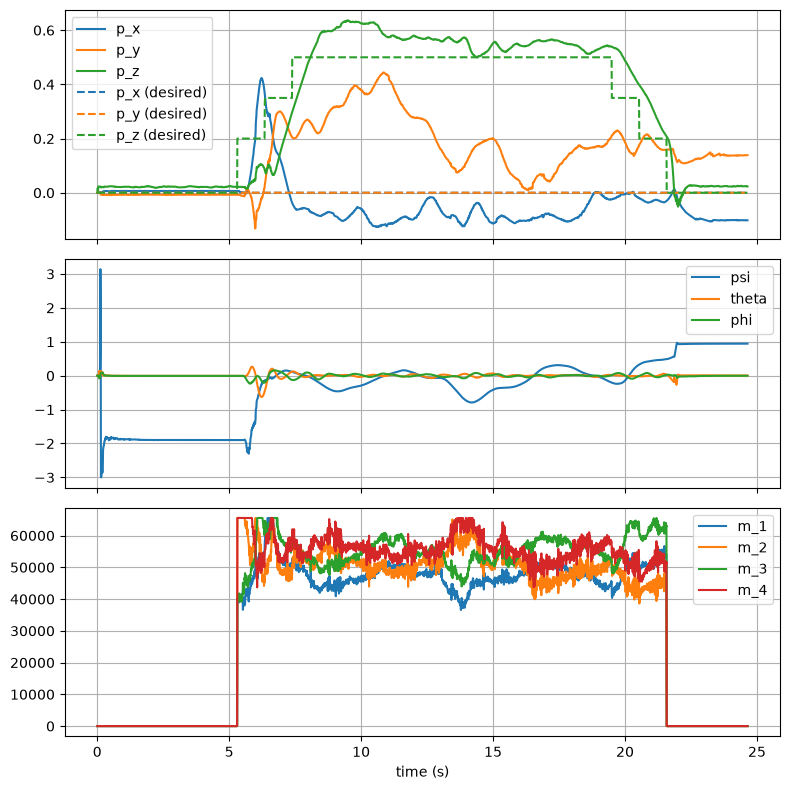

In [1076]:
fig, (ax_pos, ax_ori, ax_pow) = plt.subplots(3, 1, figsize=(8, 8), sharex=True, tight_layout=True)
px = ax_pos.plot(t, p_x, label=f'p_x')
py = ax_pos.plot(t, p_y, label=f'p_y')
pz = ax_pos.plot(t, p_z, label=f'p_z')
ax_pos.plot(t, p_x_des, '--', label=f'p_x (desired)', color=px[0].get_color())
ax_pos.plot(t, p_y_des, '--', label=f'p_y (desired)', color=py[0].get_color())
ax_pos.plot(t, p_z_des, '--', label=f'p_z (desired)', color=pz[0].get_color())
ax_pos.legend()
ax_pos.grid()
ax_ori.plot(t, psi, label='psi')
ax_ori.plot(t, theta, label='theta')
ax_ori.plot(t, phi, label='phi')
ax_ori.legend()
ax_ori.grid()
ax_pow.plot(t, m_1, label='m_1')
ax_pow.plot(t, m_2, label='m_2')
ax_pow.plot(t, m_3, label='m_3')
ax_pow.plot(t, m_4, label='m_4')
ax_pow.legend()
ax_pow.grid()
ax_pow.set_xlabel('time (s)')
plt.show()

Show the gains that were used to produce these results.

In [1077]:
show_gains(filename)

Control gains, designed 2026-10-06T18:36:28:
tau_x_cmd:     eq   0.0000    p_y  -0.0013    phi   0.0030    v_y  -0.0009    w_x   0.0005  tau_x   1.2069    e_y  -0.0002
tau_y_cmd:     eq   0.0000    p_x   0.0013  theta   0.0030    v_x   0.0009    w_y   0.0005  tau_y   1.2133    e_x   0.0002
    tau_z:     eq   0.0000    psi   0.0003    w_z   0.0001
      f_z:     eq   0.3139    p_z   0.1393    v_z   0.0946    e_z   0.0243


**Modify this cell** to describe three things:

* Your design, in particular your choice of $Q$ and $R$ (e.g., why did you make the choices you did).
* Your flight test, in particular your choice of flight trajectory (in words and with relevant code from `flight.py`) and the flight conditions (where was the flight conducted, did you power cycle the drone just before flying, what was the battery level, were you using the active marker deck, etc.).
* Your results (as shown in the plots), in particular your hypotheses about the cause of any failures (e.g., crashed drone) and about what might be done to improve performance.

Please also make clear (with justification) whether or not you believe the results obtained in this flight test are "good enough."